## Submetric : Total Crimes Per Neighborhood

### Arrest Records Dataset

For this submetric, I chose to solely focus on and analyze the amount of arrests made per neighborhood, and to what level the crime committed rose to (felony,misdemeanor,etc.)

ArrestCharge_Felony_Misdemeanor_Description  FELONY  FELONY - F1  FELONY - F2  \
Neighborhood                                                                    
Central Business District                       179           82          105   
South Side Flats                                 68           74          125   
East Allegheny                                  104           55           52   
Carrick                                          24           34           64   
Knoxville                                        22           54           85   
...                                             ...          ...          ...   
Regent Square                                     0            0            1   
Saint Clair                                       0            1            1   
Ridgemont                                         0            3            0   
Chartiers                                         0            2            0   
Swisshelm Park              

Text(0, 0.5, 'Neighborhood')

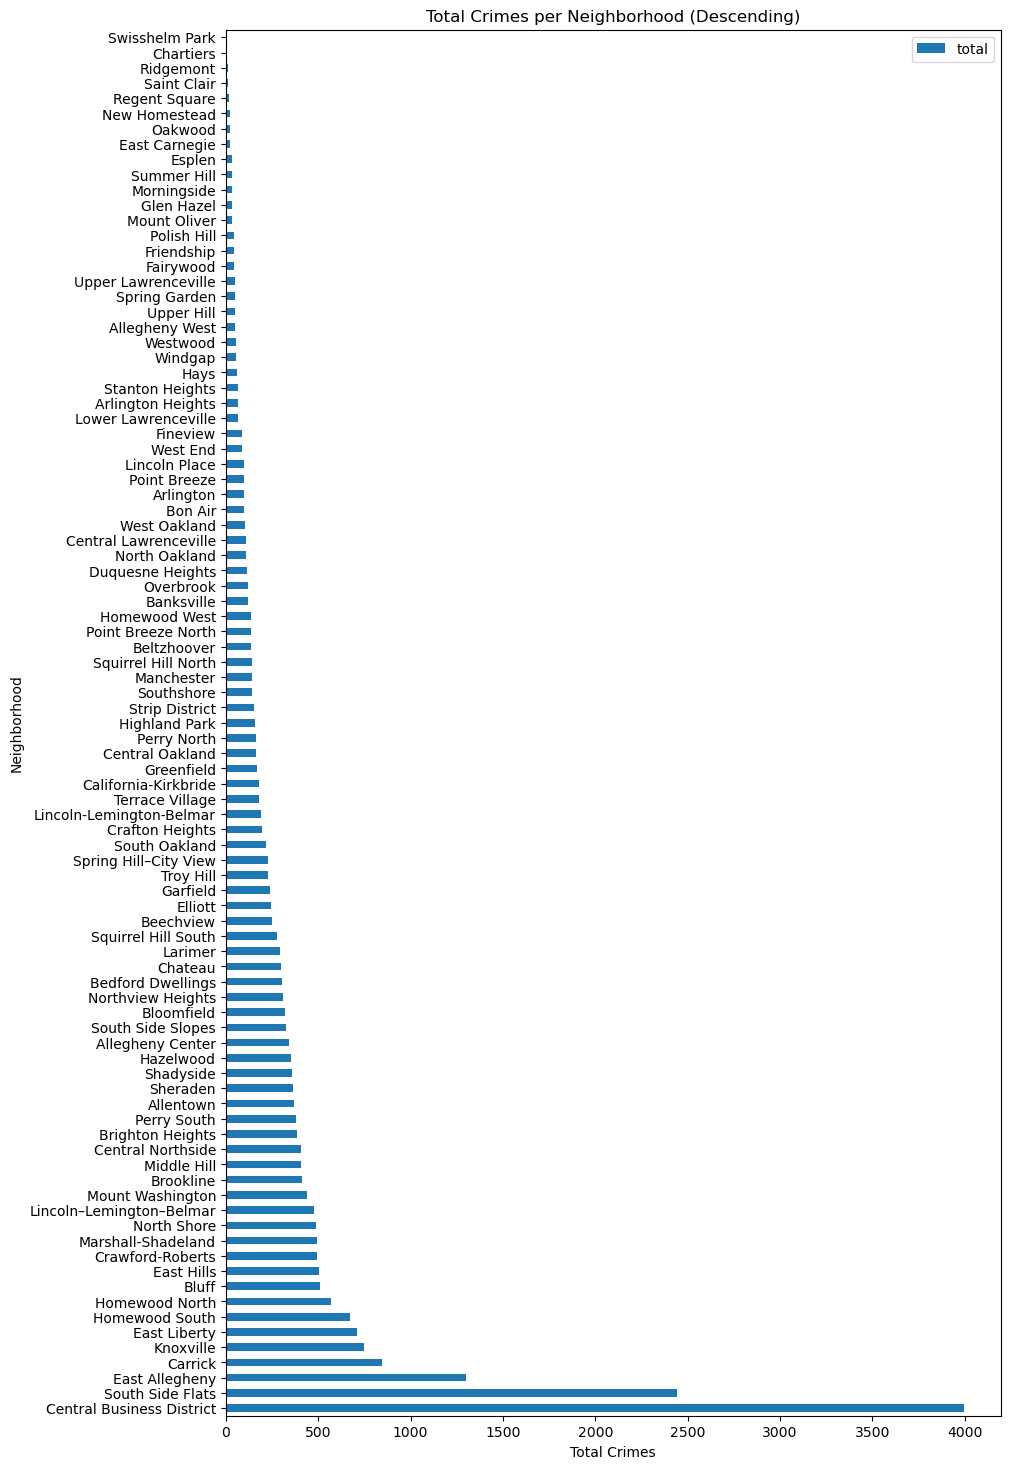

In [ ]:
import pandas as pd
df = pd.read_csv("pbp_arrests_2024_jan1_thru_oct31_2025.csv")

crime_levels = (
    df.groupby(['Neighborhood', 'ArrestCharge_Felony_Misdemeanor_Description'])
    .size()  # counts how many arrests in each group
    .unstack(fill_value=0)  # gives each offense level it's own column and fills in blank/missing columns with 0
    .reset_index()  # turns the index into normal columns
)

# Calculate total crimes
columns_to_sum = [
    'FELONY - F3', 'FELONY - F2', 'FELONY - F1',
    'MISDEMEANOR - M3', 'MISDEMEANOR - M2', 'MISDEMEANOR - M1',
    'INFRACTION - S', 'FELONY', 'MISDEMEANOR', 'INFRACTION'
]
crime_levels['total'] = crime_levels[columns_to_sum].sum(axis=1)

crime_levels_sorted = crime_levels.sort_values('total', ascending=False)
crime_levels_sorted = crime_levels_sorted.set_index('Neighborhood')

print(crime_levels_sorted)

bg = crime_levels_sorted.plot.barh(
    y='total',
    figsize=(10, 18),
    title='Total Crimes per Neighborhood (Descending)'
)

bg.set_xlabel("Total Crimes")
bg.set_ylabel("Neighborhood")

### Conclusion:

As you can see, Swisshelm Park and Chartiers are tied in this graph for the lowest crimes total per neighborhood as they only had 9 total crimes within their neighborhood with no felonies. If you scroll down, you can see that the Central business district was by far the worst when it comes to just the total crimes within a neighborhood. This data seems to make sense as Swisshelm Park and Chartiers are relatively small neighborhoods compared to the central business district. Since the central business district most likely has a higher population of people pass through it than the other two neighborhoods, it isn't too surprising that it would have more crime overall. I would prefer to live in the central business district if I were to live in Pittsburgh because it is the most diverse neighborhood and has the most things to do. Overall, if you are strictly looking for the safest neighborhood to live in, Swisshelm Park or Chartiers would be the best options. 